In [ ]:
#!/bin/bash
#!kaggle datasets download imsparsh/flowers-dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/DIT/coursDeepLearning2026/Chapitre 3 cnn/cnn_transfert_learning

/content/drive/MyDrive/DIT/coursDeepLearning2026/Chapitre 3 cnn/cnn_transfert_learning


In [ ]:
#!pip install -r requirements.txt -q

In [5]:
!pip install livelossplot -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 9.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# Restart the Kernel NOW!

> **NOTE: Wait for the previous cell to complete, then restart the kernel before running the next cell. This ensures that the dependencies we have just installed will work. Otherwise you may receive an error when running imports in the next cell!**

# Apprentissage par transfert

Dans de nombreuses situations réelles, vous ne souhaiterez pas entraîner un réseau convolutionnel complet à partir de zéro, sauf si vous disposez d’un très grand jeu de données et de ressources de calcul importantes. L’entraînement d’un réseau CNN moderne sur un jeu de données comme ImageNet peut prendre plusieurs jours, voire des semaines, sur plusieurs GPU. Dans la plupart des cas, vous utiliserez donc une approche appelée apprentissage par transfert.




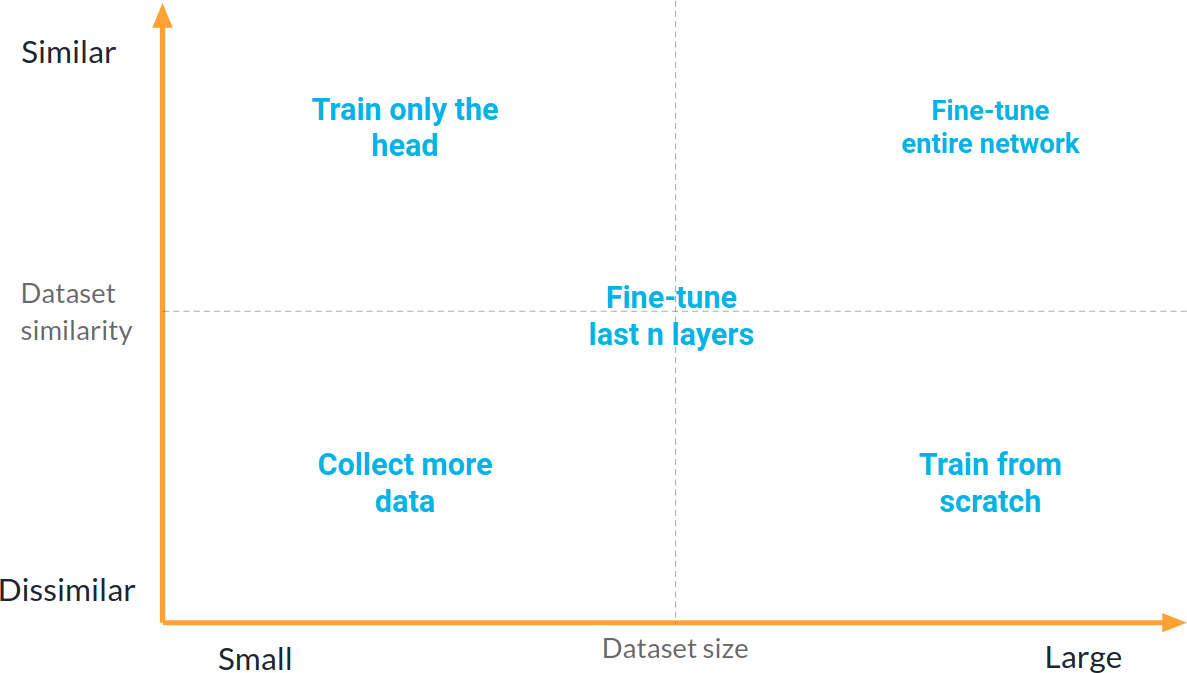


Dans ce notebook, vous allez travailler sur un petit jeu de données comportant moins de 5000 images naturelles. Comme le suggère le schéma ci-dessus, dans un cas comme celui-ci, vous pouvez utiliser un réseau pré-entraîné comme extracteur de caractéristiques et remplacer la tête du réseau. Puisque 5000 images représentent un jeu de données modeste mais pas minuscule, vous pouvez également essayer d’améliorer les performances en réentraînant légèrement le reste du réseau. Il faudra alors utiliser un taux d’apprentissage suffisamment faible pour ne pas détruire les filtres que le réseau a appris sur ImageNet.

Dans cet exercice, vous allez charger un modèle ResNet pré-entraîné, supprimer sa tête de classification et la remplacer par la vôtre. Ensuite, vous fixerez la partie extractrice de caractéristiques et entraînerez uniquement la tête. Avec cette technique d’apprentissage par transfert, il est relativement facile d’atteindre une précision d’environ 90 %. Ensuite, vous effectuerez le fine-tuning du reste du réseau. Faites bien attention à utiliser un petit taux d’apprentissage. Un peu d’expérimentation est souvent nécessaire pour trouver la bonne valeur. Ici, nous utiliserons 1/100e du taux d’apprentissage initial.

Commençons par importer quelques modules et fonctions :

In [3]:
%ls

datasets/   lr_finder.py     my_helpers.py  requirements.txt
initial.pt  mean_and_std.pt  __pycache__/   transfer_learning.ipynb


In [6]:
import torchvision.datasets
import torchvision.transforms as T
import torchvision.models
import torch.optim
from torch import nn
from my_helpers import *
import timm
from lr_finder import lr_finder
import glob
import matplotlib.pyplot as plt

Maintenant, créons les chargeurs de données.

Lorsque le jeu de données est petit, il est difficile de le diviser en trois parties (entraînement, validation et test) car il se peut que vous n’ayez pas assez de données pour chacune. À la place, vous pouvez utiliser la validation croisée en k plis : vous divisez le jeu de données en k parties, puis vous répétez l’entraînement k fois, en prenant à chaque itération k−1 parties comme jeu d’entraînement et la k-ième partie restante comme validation. Vous enregistrez vos métriques à chaque itération, puis vous utilisez la performance moyenne comme métrique.

Pour aller plus vite dans cet exercice, nous n’allons pas faire de validation croisée en k plis, mais nous allons quand même ne scinder les données qu’en entraînement et validation (en pratique, nous exécuterons seulement l’un des k entraînements d’une validation croisée en k plis).

Par simplicité, nous fournissons le code dans le fichier `helpers.py`. N’hésitez pas à y jeter un œil pour voir comment les données sont chargées. Notez que, lors de la première exécution, le code calcule la moyenne et l’écart type du jeu de données, qui seront utilisés dans la transformation `Normalize` des chargeurs de données (voir le code dans `helpers.py` pour les détails).


In [ ]:
import os
os.path.exists("datasets")

True

In [7]:
data_loaders = get_data_loaders(batch_size=32, rand_augment_magnitude=15)

Reusing cached mean and std
Dataset mean: tensor([0.4665, 0.4251, 0.3047]), std: tensor([0.3011, 0.2718, 0.2953])
Reusing cached mean and std


In [8]:
classes = ["daisy", "tulip", "dandelion", "sunflower", "rose"]

# Créer le modèle et remplacer la tête

Chargeons maintenant un modèle préentraîné et remplaçons sa tête. Utilisons un modèle ResNet de `torchvision` et remplaçons sa tête par une couche entièrement connectée (`Linear`) avec les dimensions d’entrée et de sortie appropriées :


In [9]:
model = torchvision.models.resnet50(pretrained=True)





/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


In [10]:
model.fc

Linear(in_features=2048, out_features=1000, bias=True)

In [11]:
n_classes = len(classes)
n_inputs = model.fc.in_features

In [12]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [13]:
print("head inputs : " ,n_inputs)

head inputs :  2048


In [14]:
# Feel free to experiment with more complicated heads
model.fc = nn.Sequential(
        nn.Linear(n_inputs, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, n_classes))

In [15]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Nous aurions pu faire la même chose en utilisant **TIMM** :


In [ ]:
# Nous pouvons également utiliser TIMM pour obtenir un modèle préentraîné
# model = timm.create_model("resnet18", pretrained=True, num_classes=n_classes)


## Geler le backbone et dégeler la tête

Nous devons maintenant geler toutes les couches, sauf celle que nous venons d’ajouter. Gardons une trace des paramètres que nous figeons afin de pouvoir les libérer plus tard :


In [16]:
frozen_parameters = []

for p in model.parameters():
    # Geler uniquement les paramètres qui ne le sont pas déjà
    # (le cas échéant)
    if p.requires_grad:
        p.requires_grad = False
        frozen_parameters.append(p)

print(f"{len(frozen_parameters)} groupes de paramètres ont été gelés")

# Maintenant, dégelons les paramètres de la tête que nous avons ajoutée
for p in model.fc.parameters():
    p.requires_grad = True


163 groupes de paramètres ont été gelés


## Entraînement

Nous pouvons maintenant entraîner notre modèle. Commençons par utiliser le chercheur de taux d’apprentissage habituel (*learning rate finder*) :


In [17]:
loss = nn.CrossEntropyLoss()

In [ ]:
#losses = lr_finder(1e-5, 0.1, 100, loss, model, data_loaders)

In [18]:
#_ = plt.plot(losses.keys(), losses.values())
#_ = plt.xscale("log")

# Vous devrez peut-être ajuster cette partie pour couvrir
# correctement l’axe des ordonnées (y) et mieux visualiser
# la diminution de la perte avant qu’elle ne remonte brusquement
#_ = plt.ylim([1.57, 1.75])


Il semble qu’un bon taux d’apprentissage soit **0,005**.
Commençons par entraîner uniquement la tête pendant quelques époques, afin d’ajuster ses poids (qui sont pour l’instant initialisés aléatoirement) de manière à ce qu’ils interagissent correctement avec la partie d’extraction de caractéristiques :


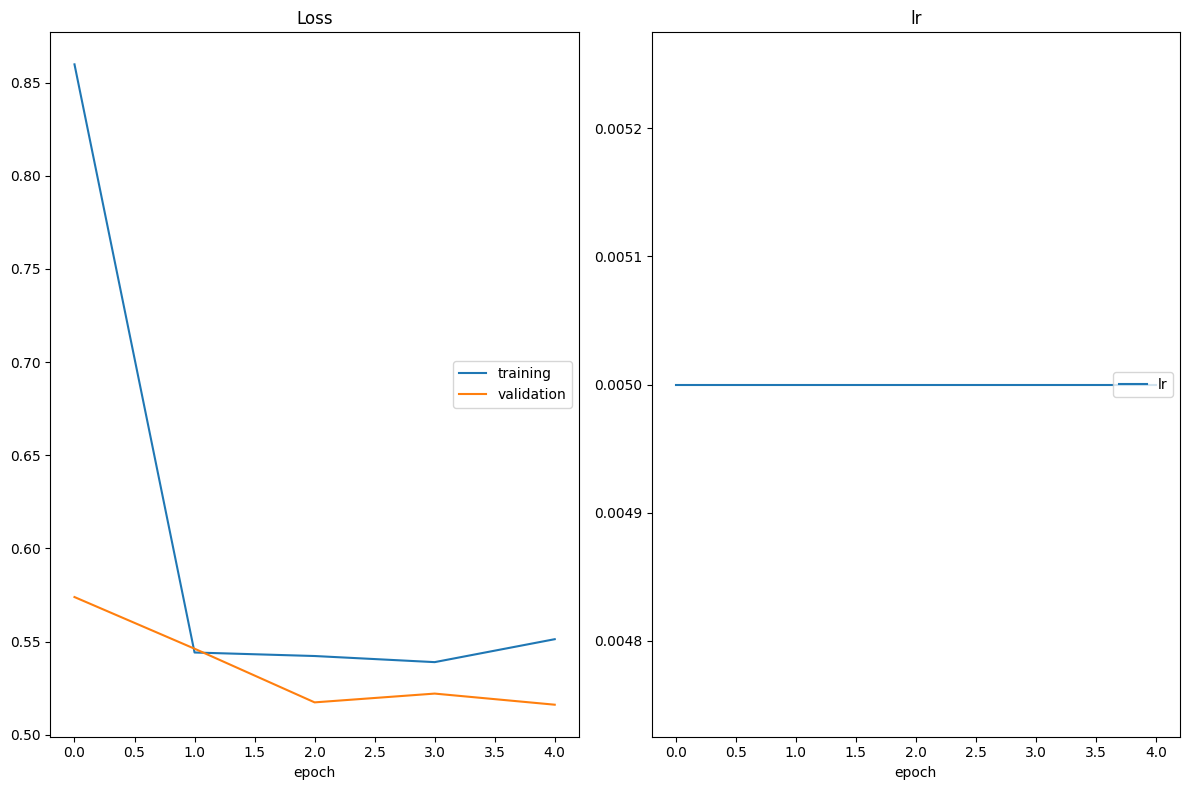

In [19]:
n_epochs = 5
lr = 0.005

optimizer = torch.optim.Adam(model.parameters(), lr)

optimize(
    data_loaders,
    model,
    optimizer,
    loss,
    n_epochs,
    'initial.pt',
    interactive_tracking=True
)

In [20]:
_ = one_epoch_test(data_loaders['valid'], model, loss)

Testing: 100%|██████████████████████████████████| 23/23 [00:06<00:00,  3.45it/s]

Test Loss: 0.516223


Test Accuracy: 72% (535/734)


Rien qu’en entraînant la nouvelle tête pendant quelques époques, nous avons déjà atteint une très bonne performance. Dégelons maintenant les paramètres que nous avions précédemment gelés :


In [21]:
# Thaw parameters we had frozen before
for p in frozen_parameters:
    p.requires_grad = True

et procédons au **fine-tuning** du modèle. Remarquez que nous utilisons un taux d’apprentissage bien plus faible que précédemment. Cela permet d’éviter de grands pas de mise à jour qui annuleraient l’avantage d’utiliser un réseau préentraîné.


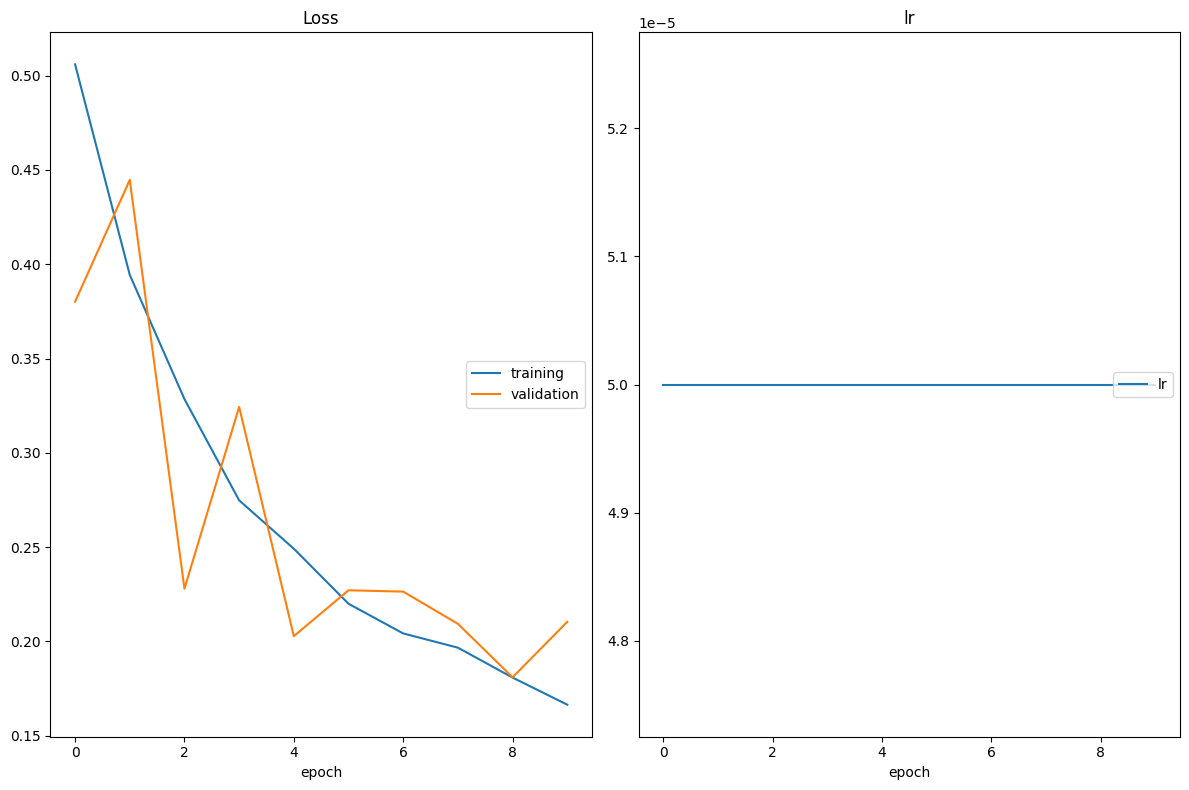

In [22]:
n_epochs = 10
lr = 0.005 / 100

optimizer = torch.optim.Adam(model.parameters(), lr)


optimize(
    data_loaders,
    model,
    optimizer,
    loss,
    n_epochs,
    "best.pt",
    interactive_tracking=True,
)

In [23]:
_ = one_epoch_test(data_loaders['valid'], model, loss)

Testing: 100%|██████████████████████████████████| 23/23 [00:04<00:00,  4.78it/s]

Test Loss: 0.210326


Test Accuracy: 92% (679/734)


Avec le **fine-tuning**, nous avons considérablement amélioré notre performance pour atteindre **95 %** !

Voyons maintenant ce qui se passerait si nous entraînions le modèle **à partir de zéro**.

Le code suivant réalise exactement cela. Nous l’avons déjà exécuté, car l’entraînement prend beaucoup de temps. Comme vous pouvez le constater, malgré un entraînement **10 fois plus long** que celui utilisant l’apprentissage par transfert, les performances obtenues sont **nettement inférieures** !

Pouvez-vous expliquer pourquoi ?


In [24]:
# Let's train from scratch
model = torchvision.models.resnet50(pretrained=False)
n_classes = len(classes)
n_inputs = model.fc.in_features
model.fc = nn.Linear(n_inputs, n_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [25]:
loss = nn.CrossEntropyLoss()

In [26]:
losses = lr_finder(1e-5, 0.2, 100, loss, model, data_loaders)

Learning rate finder:   8%|█▋                    | 7/92 [00:03<00:39,  2.14it/s]


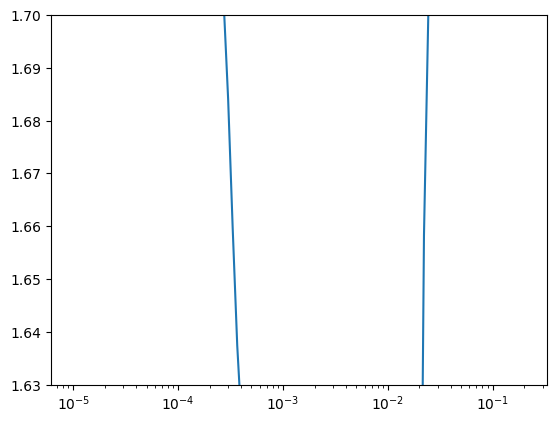

In [27]:
_ = plt.plot(losses.keys(), losses.values())
_ = plt.xscale("log")
_ = plt.ylim([1.63, 1.7])

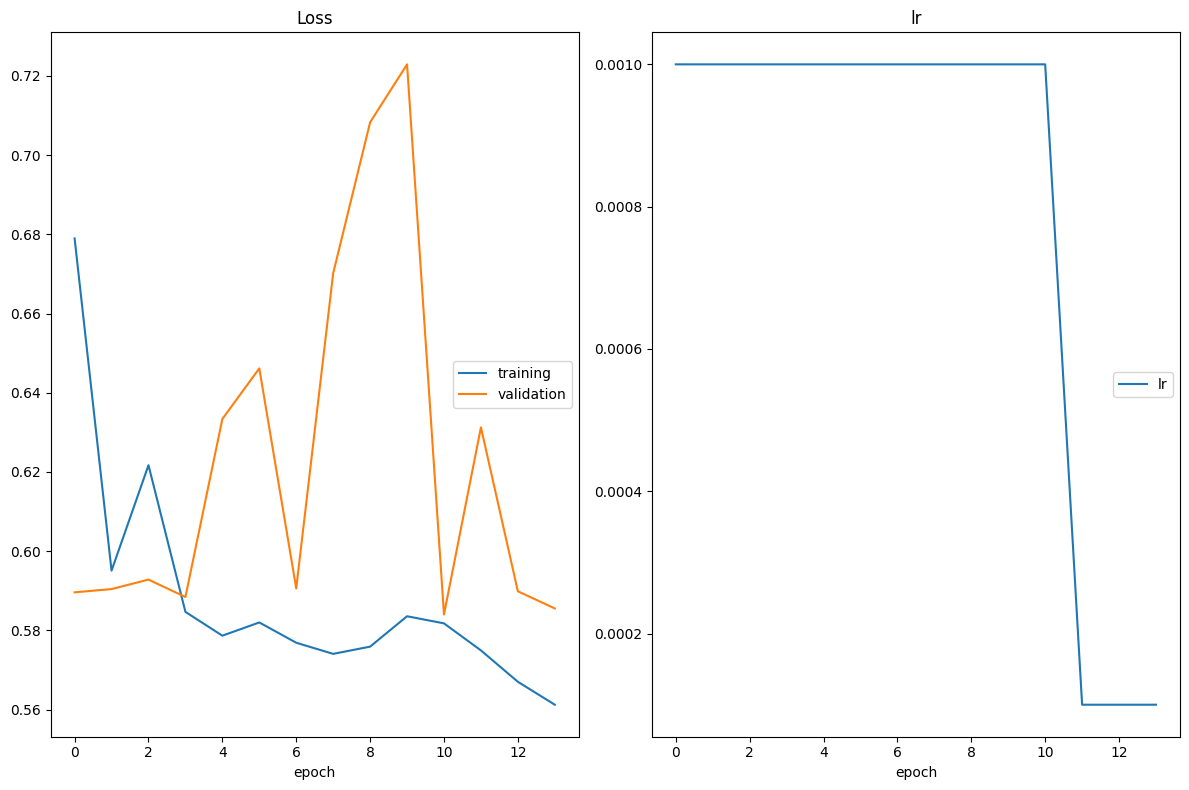

Training on GPU


Training:  21%|██████▊                          | 19/92 [00:07<00:27,  2.69it/s]


KeyboardInterrupt: 

In [28]:
optimize(data_loaders,
         model,
         torch.optim.Adam(model.parameters(), 0.001),
         loss,
         100,
         'best_scratch.pt',
         interactive_tracking=True)

In [29]:
_ = one_epoch_test(data_loaders['valid'], model, loss)

Testing: 100%|██████████████████████████████████| 23/23 [00:04<00:00,  4.89it/s]

Test Loss: 0.595849


Test Accuracy: 72% (535/734)
